# 1. Purpose

Test whether C-MAPSS FD001 contains useful near-term failure signal under an engine-disjoint validation design. The experiment predicts whether an engine has 30 or fewer cycles remaining using a fixed dummy, age-only, linear, and nonlinear baseline ladder. The 30-cycle horizon is a provisional analytical assumption, not an approved maintenance window. No tuning, threshold optimization, explainability stack, or deployment work is performed.

# 2. Imports and Configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
HORIZON_CYCLES = 30
DEFAULT_THRESHOLD = 0.50
TARGET_COL = "failure_within_30_cycles"
UNIT_COL = "unit_number"

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

# 3. Load Data

Only the complete FD001 training trajectories are loaded. The official NASA test trajectories and endpoint RUL file remain untouched for a later final assessment. RUL and failure cycle are derived retrospectively only to create and audit the outcome; neither can enter the feature set.

In [2]:
working_directory = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate
    for candidate in [working_directory, *working_directory.parents]
    if (candidate / "README.md").exists() and (candidate / "data").exists()
)
TRAIN_PATH = PROJECT_ROOT / "data" / "raw" / "cmapss" / "train_FD001.txt"

COLUMNS = (
    ["unit_number", "cycle"]
    + [f"operational_setting_{index}" for index in range(1, 4)]
    + [f"sensor_{index}" for index in range(1, 22)]
)

df = pd.read_csv(TRAIN_PATH, sep=r"\s+", header=None, names=COLUMNS)
df["failure_cycle"] = df.groupby(UNIT_COL)["cycle"].transform("max")
df["rul"] = df["failure_cycle"] - df["cycle"]
df[TARGET_COL] = (df["rul"] <= HORIZON_CYCLES).astype("int8")

assert df.shape == (20_631, 29)
assert df[UNIT_COL].nunique() == 100
assert df[[UNIT_COL, "cycle"]].duplicated().sum() == 0

display(pd.DataFrame({
    "rows": [len(df)],
    "engines": [df[UNIT_COL].nunique()],
    "positive_rows": [int(df[TARGET_COL].sum())],
    "positive_prevalence": [df[TARGET_COL].mean()],
    "horizon_cycles": [HORIZON_CYCLES],
}))

,rows,engines,positive_rows,positive_prevalence,horizon_cycles
0,20631,100,3100,0.1503,30


# 4. Safe Feature Set

The model uses only fields approved after the Day 9 audit and Day 15 sensor-documentation resolution. `unit_number` is split control only. RUL, failure cycle, the binary target, future observations, constant channels, and near-constant sensor 6 are excluded.

In [3]:
SAFE_FEATURES = [
    "cycle",
    "operational_setting_1",
    "operational_setting_2",
    "sensor_2", "sensor_3", "sensor_4", "sensor_7",
    "sensor_8", "sensor_9", "sensor_11", "sensor_12",
    "sensor_13", "sensor_14", "sensor_15", "sensor_17",
    "sensor_20", "sensor_21",
]

EXCLUSION_POLICY = {
    "unit_number": "ID only; used for grouping and split control",
    "operational_setting_3": "constant in FD001",
    "sensor_1, sensor_5, sensor_10, sensor_16, sensor_18, sensor_19": "constant in FD001",
    "sensor_6": "near-constant in FD001",
    "rul, failure_cycle, target": "retrospective outcome or target-derived",
    "future rows and full-trajectory summaries": "unavailable at prediction time",
}

PROHIBITED_COLUMNS = {UNIT_COL, "operational_setting_3", "sensor_1", "sensor_5", "sensor_6",
                      "sensor_10", "sensor_16", "sensor_18", "sensor_19",
                      "rul", "failure_cycle", TARGET_COL}
assert not (set(SAFE_FEATURES) & PROHIBITED_COLUMNS)
assert set(SAFE_FEATURES) <= set(df.columns)

print(f"Features included ({len(SAFE_FEATURES)}):")
print(SAFE_FEATURES)
print("\nFeatures excluded and reasons:")
display(pd.Series(EXCLUSION_POLICY, name="reason").rename_axis("field_or_construct").to_frame())

Features included (17):
['cycle', 'operational_setting_1', 'operational_setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

Features excluded and reasons:


,reason
field_or_construct,
unit_number,ID only; used for grouping and split control
operational_setting_3,constant in FD001
"sensor_1, sensor_5, sensor_10, sensor_16, sensor_18, sensor_19",constant in FD001
sensor_6,near-constant in FD001
"rul, failure_cycle, target",retrospective outcome or target-derived
future rows and full-trajectory summaries,unavailable at prediction time


# 5. Train / Validation / Test Design

Engines—not rows—are randomly assigned with a fixed seed: 60 train, 20 validation, and 20 Day 16 test engines. This approximates generalization to observations from unseen engines and prevents adjacent cycles from the same trajectory crossing partitions. Model specifications are compared on validation; the test partition is opened once in Section 9.

In [4]:
engine_ids = np.array(sorted(df[UNIT_COL].unique()))
development_ids, test_ids = train_test_split(
    engine_ids, test_size=20, random_state=RANDOM_STATE
)
train_ids, validation_ids = train_test_split(
    development_ids, test_size=20, random_state=RANDOM_STATE
)

assert set(train_ids).isdisjoint(validation_ids)
assert set(train_ids).isdisjoint(test_ids)
assert set(validation_ids).isdisjoint(test_ids)
assert set(train_ids) | set(validation_ids) | set(test_ids) == set(engine_ids)

SPLITS = {
    "train": df[df[UNIT_COL].isin(train_ids)].copy(),
    "validation": df[df[UNIT_COL].isin(validation_ids)].copy(),
    "test": df[df[UNIT_COL].isin(test_ids)].copy(),
}

split_summary = pd.DataFrame([
    {
        "partition": name,
        "engines": frame[UNIT_COL].nunique(),
        "rows": len(frame),
        "positive_rows": int(frame[TARGET_COL].sum()),
        "failure_prevalence": frame[TARGET_COL].mean(),
    }
    for name, frame in SPLITS.items()
]).set_index("partition")
display(split_summary)

,engines,rows,positive_rows,failure_prevalence
partition,,,,
train,60,12686,1860,0.1466
validation,20,3875,620,0.1600
test,20,4070,620,0.1523


# 6. Naive Baseline

The most-frequent Dummy Classifier predicts no near-term failures. It establishes the no-signal reference and shows why majority-class accuracy would be misleading.

In [5]:
def evaluate_classifier(estimator, features, frame):
    y_true = frame[TARGET_COL].to_numpy()
    probability = estimator.predict_proba(frame[features])[:, 1]
    prediction = (probability >= DEFAULT_THRESHOLD).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    metrics = {
        "Precision": precision_score(y_true, prediction, zero_division=0),
        "Recall": recall_score(y_true, prediction, zero_division=0),
        "F1": f1_score(y_true, prediction, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probability),
        "PR-AUC": average_precision_score(y_true, probability),
        "Brier": brier_score_loss(y_true, probability),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }
    return metrics, probability, prediction

MODELS = {}
MODEL_FEATURES = {}
validation_records = []

dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(SPLITS["train"][SAFE_FEATURES], SPLITS["train"][TARGET_COL])
MODELS["Dummy — most frequent"] = dummy_model
MODEL_FEATURES["Dummy — most frequent"] = SAFE_FEATURES
dummy_validation, _, _ = evaluate_classifier(dummy_model, SAFE_FEATURES, SPLITS["validation"])
validation_records.append({"Model": "Dummy — most frequent", **dummy_validation})
display(pd.DataFrame([validation_records[-1]]).set_index("Model").round(4))

,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier,TN,FP,FN,TP
Model,,,,,,,,,,
Dummy — most frequent,0.0000,0.0000,0.0000,0.5000,0.1600,0.1600,3255,0,620,0


# 7. Logistic Regression

Two linear references are fixed before evaluation. Age-only Logistic Regression tests whether condition sensors add information beyond elapsed cycles. The full Logistic Regression uses all approved features. Median imputation and scaling are fitted inside each training-only pipeline; balanced weights address the asymmetric class counts without changing the 0.50 decision threshold.

In [6]:
def make_logistic_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1_000,
            random_state=RANDOM_STATE,
        )),
    ])

linear_specs = {
    "Age-only Logistic Regression": (["cycle"], make_logistic_pipeline()),
    "Logistic Regression": (SAFE_FEATURES, make_logistic_pipeline()),
}

for model_name, (features, estimator) in linear_specs.items():
    estimator.fit(SPLITS["train"][features], SPLITS["train"][TARGET_COL])
    MODELS[model_name] = estimator
    MODEL_FEATURES[model_name] = features
    validation_metrics, _, _ = evaluate_classifier(estimator, features, SPLITS["validation"])
    validation_records.append({"Model": model_name, **validation_metrics})

display(pd.DataFrame(validation_records).set_index("Model").round(4))

,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier,TN,FP,FN,TP
Model,,,,,,,,,,
Dummy — most frequent,0.0000,0.0000,0.0000,0.5000,0.1600,0.1600,3255,0,620,0
Age-only Logistic Regression,0.3945,0.5823,0.4704,0.8502,0.4509,0.1522,2701,554,259,361
Logistic Regression,0.7658,0.9387,0.8435,0.9870,0.9401,0.0431,3077,178,38,582


# 8. Nonlinear Baseline

Random Forest is the only nonlinear model. Its 200 trees, minimum leaf size of five, and balanced subsample weights were fixed before validation to provide a stable, modestly regularized comparison. No parameter search is run.

In [7]:
random_forest = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
random_forest.fit(SPLITS["train"][SAFE_FEATURES], SPLITS["train"][TARGET_COL])
MODELS["Random Forest"] = random_forest
MODEL_FEATURES["Random Forest"] = SAFE_FEATURES
forest_validation, _, _ = evaluate_classifier(random_forest, SAFE_FEATURES, SPLITS["validation"])
validation_records.append({"Model": "Random Forest", **forest_validation})

validation_comparison = pd.DataFrame(validation_records).set_index("Model")
display(validation_comparison[["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC", "Brier"]].round(4))

,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier
Model,,,,,,
Dummy — most frequent,0.0000,0.0000,0.0000,0.5000,0.1600,0.1600
Age-only Logistic Regression,0.3945,0.5823,0.4704,0.8502,0.4509,0.1522
Logistic Regression,0.7658,0.9387,0.8435,0.9870,0.9401,0.0431
Random Forest,0.8412,0.7774,0.8080,0.9824,0.9186,0.0397


# 9. Metric Comparison

All model definitions are now frozen. The 20-engine Day 16 test partition is opened once for the comparison below. PR-AUC is interpreted relative to test prevalence; accuracy is intentionally omitted because the most-frequent classifier can appear strong while missing every positive.

In [8]:
test_records = []
test_outputs = {}
for model_name, estimator in MODELS.items():
    metrics, probability, prediction = evaluate_classifier(
        estimator, MODEL_FEATURES[model_name], SPLITS["test"]
    )
    test_records.append({"Model": model_name, **metrics})
    test_outputs[model_name] = {"probability": probability, "prediction": prediction}

test_comparison = pd.DataFrame(test_records).set_index("Model")
metric_columns = ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
print(f"Test failure prevalence: {SPLITS['test'][TARGET_COL].mean():.4f}")
print("A no-skill PR-AUC is approximately this prevalence.")
display(test_comparison[metric_columns].round(4))

Test failure prevalence: 0.1523
A no-skill PR-AUC is approximately this prevalence.


,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,
Dummy — most frequent,0.0000,0.0000,0.0000,0.5000,0.1523
Age-only Logistic Regression,0.4353,0.7484,0.5504,0.8999,0.6358
Logistic Regression,0.7182,0.9661,0.8239,0.9919,0.9622
Random Forest,0.8263,0.8823,0.8534,0.9899,0.9515


**Result.** Test prevalence is 15.23%. The dummy model has zero recall and PR-AUC equal to prevalence. Age-only Logistic Regression reaches PR-AUC 0.6358. Full Logistic Regression reaches recall 0.9661 and PR-AUC 0.9622, demonstrating substantial condition signal beyond age. Random Forest improves precision and F1, but its recall, ROC-AUC, and PR-AUC are lower than the full linear baseline.

# 10. Confusion Matrix Analysis

At the common 0.50 threshold, TP is a correctly identified near-term-risk row, FP is an unnecessary intervention alert, FN is missed near-term risk, and TN is a correctly avoided intervention. Rows remain repeated observations rather than independent failure events.

In [9]:
confusion_summary = test_comparison[["TN", "FP", "FN", "TP"]].astype(int)
display(confusion_summary)

,TN,FP,FN,TP
Model,,,,
Dummy — most frequent,3450,0,620,0
Age-only Logistic Regression,2848,602,156,464
Logistic Regression,3215,235,21,599
Random Forest,3335,115,73,547


**Operational interpretation.** Logistic Regression finds 599 of 620 positive rows and misses 21, but produces 235 unnecessary alerts. Random Forest reduces unnecessary alerts to 115 and correctly identifies 547 positive rows, but misses 73. With missed risk assumed much more costly than a false alert, the nonlinear model's precision improvement does not compensate for its additional misses in the prescribed cost scenario.

# 11. Probability / Calibration Check

Brier score and five-quantile reliability curves provide a basic check. This is diagnosis only: no calibrator is fitted and the test data is not used to adjust model behavior.

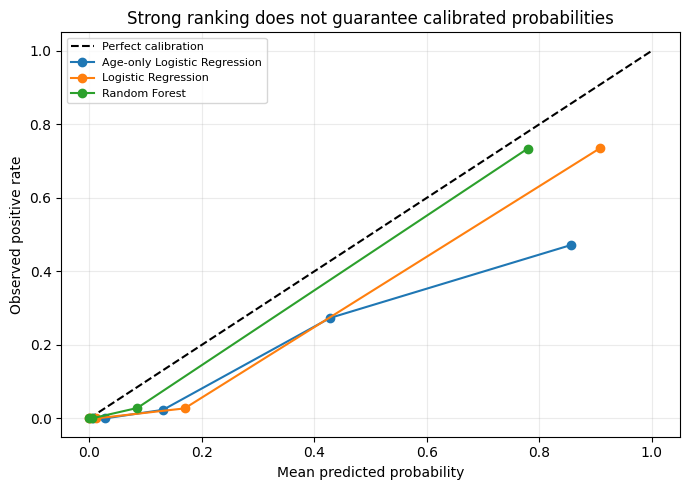

,Brier score,Mean predicted probability,Observed prevalence,Largest bin gap
Model,,,,
Age-only Logistic Regression,0.1256,0.2880,0.1523,0.3851
Logistic Regression,0.0442,0.2180,0.1523,0.1730
Random Forest,0.0303,0.1733,0.1523,0.0570


In [10]:
calibration_rows = []
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="black", label="Perfect calibration")

for model_name in ["Age-only Logistic Regression", "Logistic Regression", "Random Forest"]:
    probability = test_outputs[model_name]["probability"]
    observed_rate, mean_probability = calibration_curve(
        SPLITS["test"][TARGET_COL], probability, n_bins=5, strategy="quantile"
    )
    calibration_rows.append({
        "Model": model_name,
        "Brier score": brier_score_loss(SPLITS["test"][TARGET_COL], probability),
        "Mean predicted probability": probability.mean(),
        "Observed prevalence": SPLITS["test"][TARGET_COL].mean(),
        "Largest bin gap": np.max(np.abs(observed_rate - mean_probability)),
    })
    ax.plot(mean_probability, observed_rate, marker="o", label=model_name)

ax.set(title="Strong ranking does not guarantee calibrated probabilities",
       xlabel="Mean predicted probability", ylabel="Observed positive rate")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
display(pd.DataFrame(calibration_rows).set_index("Model").round(4))

**Finding.** Random Forest has the lowest Brier score (0.0303), followed by full Logistic Regression (0.0442) and age-only Logistic Regression (0.1256). Reliability bins still depart from the ideal diagonal, particularly for the class-weighted linear models. These probabilities are not yet reliable inputs to expected-value calculations; calibration must be evaluated without reusing this test partition.

# 12. Illustrative Business-Cost Comparison

The Day 2 assumptions supply `C_FN = Rp 58 million` and `C_FP = Rp 6 million`. The prescribed row-level comparison is `FN × C_FN + FP × C_FP` at the unchanged 0.50 threshold. It is illustrative—not realized value—because adjacent positive cycles can refer to the same future engine failure.

In [11]:
C_FN_MILLION_RP = 58
C_FP_MILLION_RP = 6
real_models = ["Age-only Logistic Regression", "Logistic Regression", "Random Forest"]
business_cost = confusion_summary.loc[real_models, ["FP", "FN"]].copy()
business_cost["Illustrative Cost (Rp million)"] = (
    business_cost["FN"] * C_FN_MILLION_RP
    + business_cost["FP"] * C_FP_MILLION_RP
)
display(business_cost)

,FP,FN,Illustrative Cost (Rp million)
Model,,,
Age-only Logistic Regression,602,156,12660
Logistic Regression,235,21,2628
Random Forest,115,73,4924


**Business interpretation.** Full Logistic Regression has the lowest illustrative cost at Rp 2,628 million, versus Rp 4,924 million for Random Forest and Rp 12,660 million for the age-only reference. The statistical and cost rankings differ: Random Forest has the highest F1 and lowest Brier score, while Logistic Regression is preferred when missed positives carry the stated larger penalty.

# 13. Error Analysis

The review is bounded to the ten most confident false negatives and false positives for each condition model. RUL appears only as retrospective diagnostic context. No threshold or model parameter is changed after inspecting these errors.

In [12]:
error_summaries = []
error_samples = []
test_context = SPLITS["test"][[UNIT_COL, "cycle", "rul", TARGET_COL]].copy()

for model_name in ["Logistic Regression", "Random Forest"]:
    review = test_context.copy()
    review["probability"] = test_outputs[model_name]["probability"]
    review["prediction"] = test_outputs[model_name]["prediction"]
    false_negatives = review[(review[TARGET_COL] == 1) & (review["prediction"] == 0)]
    false_positives = review[(review[TARGET_COL] == 0) & (review["prediction"] == 1)]

    for error_type, error_frame in [("FN", false_negatives), ("FP", false_positives)]:
        error_summaries.append({
            "Model": model_name,
            "Error": error_type,
            "Rows": len(error_frame),
            "Engines": error_frame[UNIT_COL].nunique(),
            "Median RUL": error_frame["rul"].median(),
            "Minimum RUL": error_frame["rul"].min(),
            "Maximum RUL": error_frame["rul"].max(),
        })

    fn_sample = false_negatives.sort_values("probability").head(10).assign(Model=model_name, Error="FN")
    fp_sample = false_positives.sort_values("probability", ascending=False).head(10).assign(Model=model_name, Error="FP")
    error_samples.append(pd.concat([fn_sample, fp_sample], ignore_index=True))

display(pd.DataFrame(error_summaries).set_index(["Model", "Error"]))
display(pd.concat(error_samples, ignore_index=True)[
    ["Model", "Error", UNIT_COL, "cycle", "rul", "probability"]
].round(4))

Rows  Engines  Median RUL  Minimum RUL  Maximum RUL
Model               Error                                                     
Logistic Regression FN       21        7     28.0000           21           30
                    FP      235       18     40.0000           31           86
Random Forest       FN       73       12     26.0000           12           30
                    FP      115       14     37.0000           31           86

,Model,Error,unit_number,cycle,rul,probability
0,Logistic Regression,FN,45,128,30,0.1396
1,Logistic Regression,FN,45,129,29,0.1737
2,Logistic Regression,FN,46,226,30,0.1899
3,Logistic Regression,FN,74,136,30,0.2238
4,Logistic Regression,FN,45,132,26,0.2383
5,Logistic Regression,FN,31,204,30,0.2490
6,Logistic Regression,FN,74,138,28,0.2523
7,Logistic Regression,FN,45,130,28,0.2682
8,Logistic Regression,FN,78,202,29,0.2707
9,Logistic Regression,FN,74,139,27,0.2911


**Summary.** All 21 Logistic Regression false negatives occur at RUL 21–30 across seven engines, at the early edge of the provisional alert window. Its false positives have median RUL 40 and none exceed 86 cycles, so most are close to—but outside—the binary boundary. Random Forest's 73 false negatives span 12–30 cycles across 12 engines, including 12 rows at RUL 11–20; its false positives have median RUL 37. The dominant error pattern is boundary uncertainty rather than terminal-cycle failure, reinforcing that horizon choice and calibrated probabilities matter more than a post-hoc test-set threshold adjustment.

# 14. Complexity Decision

## NOT YET

Random Forest improves test precision (0.8263 vs 0.7182), F1 (0.8534 vs 0.8239), and Brier score (0.0303 vs 0.0442). However, Logistic Regression has higher recall (0.9661 vs 0.8823), ROC-AUC (0.9919 vs 0.9899), PR-AUC (0.9622 vs 0.9515), and much lower illustrative cost (Rp 2,628M vs Rp 4,924M). Given the small simulated cohort, provisional horizon, calibration uncertainty, and greater operating complexity, the nonlinear lift is not yet decision-justified.

# 15. Limitations

- The 30-cycle target is an explicit experiment assumption, not an approved maintenance horizon.
- FD001 is simulated and represents one operating regime and fault mode.
- One 60/20/20 engine split cannot quantify uncertainty across cohorts.
- Rows within an engine are dependent; row-level metrics and costs do not represent independent failures.
- Complete run-to-failure training trajectories differ from deployment with censoring and interventions.
- Balanced class weights can weaken probability calibration.
- The default 0.50 threshold is not economically optimized.
- The illustrative cost excludes intervention outcomes, capacity, true-positive costs, and engine criticality.
- The official NASA test collection remains unexamined, so no benchmark-generalization claim is made.

# 16. Recommendation

Retain Logistic Regression as the Day 16 baseline because it demonstrates strong condition signal beyond engine age with fewer costly misses at the common threshold. Next, validate the business meaning of `H`, estimate variability with group-aware resampling, and assess calibration on development engines. Do not tune the test threshold, add explainability tooling, or open the official NASA test collection until the experiment policy is frozen.